In [2]:
import pandas
import matplotlib.pyplot as plt 

import tools

RESISTANCE = 63.43

VOLTAGE_RESOLUTION_ERROR = 5/(2**10)
MAGNETIC_RESOLUTION_ERROR = 0.4/(2**10)
VOLTAGE_INDIRECT_ERROR = (VOLTAGE_RESOLUTION_ERROR/RESISTANCE)




def get_average_magnetic_field(df: pandas.DataFrame):
    magnetic_field = df.iloc[:,1]

    return get_average_with_error(series=magnetic_field, errors=[MAGNETIC_RESOLUTION_ERROR])

def get_average_current(df: pandas.DataFrame):    
    current = df.iloc[:,1]

    return get_average_with_error(series=current, errors=[VOLTAGE_INDIRECT_ERROR])



volt_to_freq = []

magnetic_fields_no_coil = []
magnetic_fields_with_coil = []
currents = []
for i in [2,3,4,5,6,8]:
    magnet_no_coil_peak_df = pandas.read_csv(f"freq_{i}_magnet_no_coil_peaks_2.csv")
    temp_magnet_no_coil = tools.Average.from_series(series=magnet_no_coil_peak_df.iloc[:,1], errors=[MAGNETIC_RESOLUTION_ERROR])
    magnetic_fields_no_coil.append(temp_magnet_no_coil)
    
    magnet_with_coil_peak_df = pandas.read_csv(f"freq_{i}_magnet_with_coil_peaks_2.csv")
    temp_magnet_with_coil = tools.Average.from_series(series=magnet_with_coil_peak_df.iloc[:,1], errors=[MAGNETIC_RESOLUTION_ERROR])
    magnetic_fields_with_coil.append(temp_magnet_with_coil)

    current_df = pandas.read_csv(f"freq_{i}_current_peaks_2.csv")
    temp_current = tools.Average.from_series(series=current_df.iloc[:,1], errors=[VOLTAGE_INDIRECT_ERROR])
    currents.append(temp_current)
    
    volt_to_freq.append({
            "magnet_no_coil": temp_magnet_no_coil.mean,
            "magnet_no_coil_error": temp_magnet_no_coil.total_error,
            "magnet_with_coil": temp_magnet_with_coil.mean,
            "magnet_with_coil_error": temp_magnet_with_coil.total_error,
            "current": temp_current.mean,
            "current_error": temp_current.total_error
        })
    

volt_to_freq = pandas.DataFrame(volt_to_freq)

print(volt_to_freq.to_csv())

,magnet_no_coil,magnet_no_coil_error,magnet_with_coil,magnet_with_coil_error,current,current_error
0,0.008956736842105266,0.00039386974038996514,0.008901999999999998,0.00039481518444141225,0.0015341871909999975,7.707284835602936e-05
1,0.01106215873015873,0.0003946716924246254,0.01107046031746032,0.0003957205456362084,0.0012074625923128436,7.708494796518207e-05
2,0.008873556962025313,0.00039287457117991097,0.008911316455696199,0.00039268629131723856,0.0015461533171999126,7.71066197122203e-05
3,0.00720047368421053,0.0003939064606885346,0.007184958762886599,0.00039323223408057646,0.0019077974133333323,7.713286148930685e-05
4,0.010605000000000002,0.00039241112627396465,0.010757757575757573,0.0003937812814828323,0.0012634047391363395,7.710611474947148e-05
5,0.019176823529411764,0.0003927665554030293,0.01921412121212121,0.00039725378787878785,0.0006823059463302302,7.710073142122977e-05



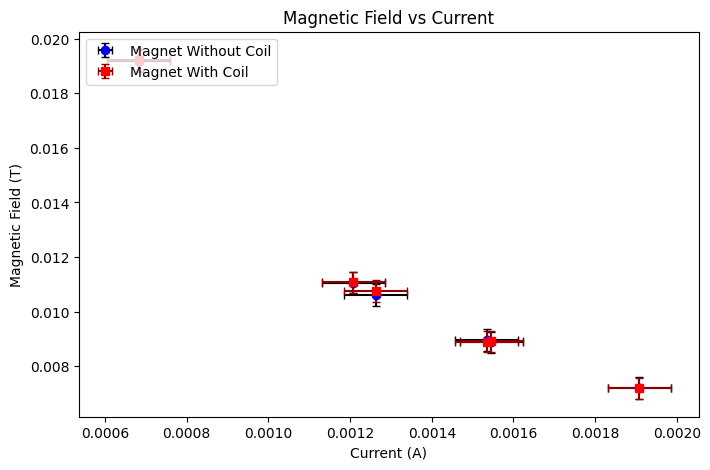

In [3]:
plt.figure(figsize=(8, 5))

tools.add_error_bar(plt, x=currents, y=magnetic_fields_no_coil, bar_config={
    "fmt": "o",           # 'o' means circular data markers
    "color": "blue", 
    "ecolor": "black",    # Error bar line color
    "capsize": 3,         # Adds little caps to the ends of error bars
    "label": "Magnet Without Coil"
})

tools.add_error_bar(plt, x=currents, y=magnetic_fields_with_coil, bar_config={
    "fmt": "s",
    "color": "red", 
    "ecolor": "darkred",    # Error bar line color
    "capsize": 3,         # Adds little caps to the ends of error bars
    "label": "Magnet With Coil"
})

plt.xlabel("Current (A)")
plt.ylabel("Magnetic Field (T)") # Update units as necessary for your lab
plt.title("Magnetic Field vs Current")
plt.legend(loc="upper left")

plt.show()